# EDA > Diagnostics

<div class="alert alert-info">Profile variables, inspect missingness, scan associations, and flag outliers.</div>

These helpers return regular Polars DataFrames, so you can filter, sort, join, or pipe them into other pyrsm EDA tools.

In [1]:
import polars as pl
import pyrsm as rsm

# Diamonds Dataset

In [2]:
diamonds = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/data/diamonds.parquet"
)
diamonds.head()

price,carat,clarity,cut,color,depth,table,x,y,z,date
i32,f64,enum,enum,enum,f64,f64,f64,f64,f64,date
580,0.32,"""VS1""","""Ideal""","""H""",61.0,56.0,4.43,4.45,2.71,2012-02-26
650,0.34,"""SI1""","""Very Good""","""G""",63.4,57.0,4.45,4.42,2.81,2012-02-26
630,0.3,"""VS2""","""Very Good""","""G""",63.1,58.0,4.27,4.23,2.68,2012-02-26
706,0.35,"""VVS2""","""Ideal""","""H""",59.2,56.0,4.6,4.65,2.74,2012-02-26
1080,0.4,"""VS2""","""Premium""","""F""",62.6,58.0,4.72,4.68,2.94,2012-02-26


In [3]:
rsm.md(
    "https://raw.githubusercontent.com/radiant-ai-hub/pyrsm/refs/heads/main/examples/data/data/diamonds_description.md"
)

## Diamond prices

Prices of 3,000 round cut diamonds

### Description

A dataset containing the prices and other attributes of a sample of 3000 diamonds. The variables are as follows:

### Variables

- price = price in US dollars ($338--$18,791)
- carat = weight of the diamond (0.2--3.00)
- clarity = a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
- cut = quality of the cut (Fair, Good, Very Good, Premium, Ideal)
- color = diamond color, from J (worst) to D (best)
- depth = total depth percentage = z / mean(x, y) = 2 * z / (x + y) (54.2--70.80)
- table = width of top of diamond relative to widest point (50--69)
- x = length in mm (3.73--9.42)
- y = width in mm (3.71--9.29)
- z = depth in mm (2.33--5.58)
- date = shipment date

### Additional information

<a href="http://www.diamondse.info/diamonds-clarity.asp" target="_blank">Diamond search engine</a>


## Profile

`profile` gives one row per variable with dtype, inferred type, missingness, unique counts, numeric summaries, and top values.

In [4]:
rsm.eda.profile(diamonds)

variable,dtype,type,n,n_complete,n_missing,pct_missing,n_unique,pct_unique,mean,median,sd,min,max,mode,mode_count,top_values
str,str,str,i64,i64,i64,f64,i64,f64,f64,f64,f64,str,str,str,i64,str
"""price""","""Int32""","""numeric""",3000,3000,0,0.0,2169,0.723,3907.186,2407.0,3956.9154,"""338""","""18791""","""743""",10,"""743: 10 (0.3%); 596: 9 (0.3%); 776: 9 (0.3%)"""
"""carat""","""Float64""","""numeric""",3000,3000,0,0.0,201,0.067,0.794283,0.7,0.473826,"""0.2""","""3.0""","""0.3""",157,"""0.3: 157 (5.2%); 0.31: 139 (4.6%); 1.01: 118 (3.9%)"""
"""clarity""","""Enum(categories=['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'])""","""categorical""",3000,3000,0,0.0,8,0.002667,null,null,null,null,null,"""SI1""",721,"""SI1: 721 (24.0%); VS2: 661 (22.0%); SI2: 529 (17.6%)"""
"""cut""","""Enum(categories=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'])""","""categorical""",3000,3000,0,0.0,5,0.001667,null,null,null,null,null,"""Ideal""",1176,"""Ideal: 1176 (39.2%); Premium: 771 (25.7%); Very Good: 677 (22.6%)"""
"""color""","""Enum(categories=['D', 'E', 'F', 'G', 'H', 'I', 'J'])""","""categorical""",3000,3000,0,0.0,7,0.002333,null,null,null,null,null,"""G""",597,"""G: 597 (19.9%); F: 565 (18.8%); E: 554 (18.5%)"""
"""depth""","""Float64""","""numeric""",3000,3000,0,0.0,115,0.038333,61.752667,61.9,1.446028,"""54.2""","""70.8""","""62.0""",134,"""62.0: 134 (4.5%); 62.2: 126 (4.2%); 62.3: 115 (3.8%)"""
"""table""","""Float64""","""numeric""",3000,3000,0,0.0,57,0.019,57.465333,57.0,2.241102,"""50.0""","""69.0""","""57.0""",538,"""57.0: 538 (17.9%); 56.0: 516 (17.2%); 58.0: 484 (16.1%)"""
"""x""","""Float64""","""numeric""",3000,3000,0,0.0,446,0.148667,5.721823,5.71,1.124055,"""3.73""","""9.42""","""4.35""",30,"""4.35: 30 (1.0%); 4.39: 27 (0.9%); 4.33: 26 (0.9%)"""
"""y""","""Float64""","""numeric""",3000,3000,0,0.0,450,0.15,5.7233,5.72,1.114313,"""3.71""","""9.26""","""4.35""",32,"""4.35: 32 (1.1%); 4.31: 30 (1.0%); 4.77: 29 (1.0%)"""


In [5]:
rsm.eda.profile(diamonds, cols=["price", "carat", "cut", "color"])

variable,dtype,type,n,n_complete,n_missing,pct_missing,n_unique,pct_unique,mean,median,sd,min,max,mode,mode_count,top_values
str,str,str,i64,i64,i64,f64,i64,f64,f64,f64,f64,str,str,str,i64,str
"""price""","""Int32""","""numeric""",3000,3000,0,0.0,2169,0.723,3907.186,2407.0,3956.9154,"""338""","""18791""","""743""",10,"""743: 10 (0.3%); 596: 9 (0.3%); 776: 9 (0.3%)"""
"""carat""","""Float64""","""numeric""",3000,3000,0,0.0,201,0.067,0.794283,0.7,0.473826,"""0.2""","""3.0""","""0.3""",157,"""0.3: 157 (5.2%); 0.31: 139 (4.6%); 1.01: 118 (3.9%)"""
"""cut""","""Enum(categories=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'])""","""categorical""",3000,3000,0,0.0,5,0.001667,null,null,null,null,null,"""Ideal""",1176,"""Ideal: 1176 (39.2%); Premium: 771 (25.7%); Very Good: 677 (22.6%)"""
"""color""","""Enum(categories=['D', 'E', 'F', 'G', 'H', 'I', 'J'])""","""categorical""",3000,3000,0,0.0,7,0.002333,null,null,null,null,null,"""G""",597,"""G: 597 (19.9%); F: 565 (18.8%); E: 554 (18.5%)"""


In [6]:
(rsm.eda.profile(diamonds).filter(pl.col("type") == "numeric").sort("n_unique", descending=True))

variable,dtype,type,n,n_complete,n_missing,pct_missing,n_unique,pct_unique,mean,median,sd,min,max,mode,mode_count,top_values
str,str,str,i64,i64,i64,f64,i64,f64,f64,f64,f64,str,str,str,i64,str
"""price""","""Int32""","""numeric""",3000,3000,0,0.0,2169,0.723,3907.186,2407.0,3956.9154,"""338""","""18791""","""743""",10,"""743: 10 (0.3%); 596: 9 (0.3%); 776: 9 (0.3%)"""
"""y""","""Float64""","""numeric""",3000,3000,0,0.0,450,0.15,5.7233,5.72,1.114313,"""3.71""","""9.26""","""4.35""",32,"""4.35: 32 (1.1%); 4.31: 30 (1.0%); 4.77: 29 (1.0%)"""
"""x""","""Float64""","""numeric""",3000,3000,0,0.0,446,0.148667,5.721823,5.71,1.124055,"""3.73""","""9.42""","""4.35""",30,"""4.35: 30 (1.0%); 4.39: 27 (0.9%); 4.33: 26 (0.9%)"""
"""z""","""Float64""","""numeric""",3000,3000,0,0.0,299,0.099667,3.533447,3.52,0.693858,"""2.33""","""5.58""","""2.71""",49,"""2.71: 49 (1.6%); 2.68: 44 (1.5%); 2.72: 44 (1.5%)"""
"""carat""","""Float64""","""numeric""",3000,3000,0,0.0,201,0.067,0.794283,0.7,0.473826,"""0.2""","""3.0""","""0.3""",157,"""0.3: 157 (5.2%); 0.31: 139 (4.6%); 1.01: 118 (3.9%)"""
"""depth""","""Float64""","""numeric""",3000,3000,0,0.0,115,0.038333,61.752667,61.9,1.446028,"""54.2""","""70.8""","""62.0""",134,"""62.0: 134 (4.5%); 62.2: 126 (4.2%); 62.3: 115 (3.8%)"""
"""table""","""Float64""","""numeric""",3000,3000,0,0.0,57,0.019,57.465333,57.0,2.241102,"""50.0""","""69.0""","""57.0""",538,"""57.0: 538 (17.9%); 56.0: 516 (17.2%); 58.0: 484 (16.1%)"""


## Missing Values

The diamonds data are complete, so the next cell creates a small reproducible missing-data example.

In [7]:
diamonds_missing = (
    diamonds.with_row_index("row_nr")
    .with_columns(
        price=pl.when(pl.col("row_nr") % 17 == 0).then(None).otherwise(pl.col("price")),
        cut=pl.when(pl.col("row_nr") % 23 == 0).then(None).otherwise(pl.col("cut")),
    )
    .drop("row_nr")
)

rsm.eda.missing(diamonds_missing, cols=["price", "carat", "cut", "color"])

variable,dtype,n,n_missing,pct_missing,n_complete,pct_complete
str,str,i64,i64,f64,i64,f64
"""price""","""Int32""",3000,177,0.059,2823,0.941
"""carat""","""Float64""",3000,0,0.0,3000,1.0
"""cut""","""Enum(categories=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'])""",3000,131,0.043667,2869,0.956333
"""color""","""Enum(categories=['D', 'E', 'F', 'G', 'H', 'I', 'J'])""",3000,0,0.0,3000,1.0


In [8]:
rsm.eda.missing(diamonds_missing, cols=["price", "cut"], by="color")

color,n,price_n_missing,cut_n_missing,price_pct_missing,cut_pct_missing
enum,u32,u32,u32,f64,f64
"""H""",454,32,27,0.070485,0.059471
"""G""",597,28,24,0.046901,0.040201
"""F""",565,33,20,0.058407,0.035398
"""E""",554,34,25,0.061372,0.045126
"""I""",284,18,17,0.06338,0.059859
"""D""",382,26,16,0.068063,0.041885
"""J""",164,6,2,0.036585,0.012195


In [9]:
rsm.eda.missing(diamonds_missing, cols=["price", "cut", "color"], patterns=True)

price,cut,color,n,pct
i8,i8,i8,u32,f64
0,0,0,2700,0.9
1,0,0,169,0.056333
0,1,0,123,0.041
1,1,0,8,0.002667


## Associations

`associations` chooses the metric from the variable types: Pearson/Spearman for numeric pairs, eta-squared for categorical-numeric pairs, and Cramer's V for categorical pairs.

In [10]:
rsm.eda.associations(
    diamonds,
    cols=["carat", "depth", "table", "cut", "color", "clarity"],
    target="price",
)

var1,var2,type1,type2,association_type,metric,value,p_value,n
str,str,str,str,str,str,f64,f64,i64
"""carat""","""price""","""numeric""","""numeric""","""numeric_numeric""","""pearson""",0.927332,0.0,3000
"""table""","""price""","""numeric""","""numeric""","""numeric_numeric""","""pearson""",0.140441,1.0978e-14,3000
"""clarity""","""price""","""categorical""","""numeric""","""categorical_numeric""","""eta_squared""",0.031186,1.2306e-17,3000
"""color""","""price""","""categorical""","""numeric""","""categorical_numeric""","""eta_squared""",0.026515,2.8376e-15,3000
"""cut""","""price""","""categorical""","""numeric""","""categorical_numeric""","""eta_squared""",0.009391,0.000011,3000
"""depth""","""price""","""numeric""","""numeric""","""numeric_numeric""","""pearson""",-0.011214,0.539241,3000


In [11]:
rsm.eda.associations(diamonds, cols=["price", "carat", "depth", "table"], method="spearman")

var1,var2,type1,type2,association_type,metric,value,p_value,n
str,str,str,str,str,str,f64,f64,i64
"""price""","""carat""","""numeric""","""numeric""","""numeric_numeric""","""spearman""",0.961908,0.0,3000
"""carat""","""table""","""numeric""","""numeric""","""numeric_numeric""","""spearman""",0.189191,1.4250e-25,3000
"""price""","""table""","""numeric""","""numeric""","""numeric_numeric""","""spearman""",0.169789,7.6843e-21,3000
"""carat""","""depth""","""numeric""","""numeric""","""numeric_numeric""","""spearman""",0.034586,0.058211,3000
"""price""","""depth""","""numeric""","""numeric""","""numeric_numeric""","""spearman""",0.016187,0.375469,3000
"""depth""","""table""","""numeric""","""numeric""","""numeric_numeric""","""spearman""",-0.235858,3.3674e-39,3000


## Outliers

`outliers` is diagnostic only. It reports likely outliers or returns row-level flags; it never removes rows.

In [12]:
rsm.eda.outliers(diamonds, cols=["price", "carat", "depth", "table"])

variable,method,threshold,n,n_outliers,pct_outliers,lower,upper,min,max
str,str,f64,i64,i64,f64,f64,f64,f64,f64
"""price""","""iqr""",1.5,3000,199,0.066333,-5562.0,11774.0,338.0,18791.0
"""carat""","""iqr""",1.5,3000,83,0.027667,-0.585,2.015,0.2,3.0
"""depth""","""iqr""",1.5,3000,173,0.057667,59.0,64.6,54.2,70.8
"""table""","""iqr""",1.5,3000,38,0.012667,51.5,63.5,50.0,69.0


In [13]:
rsm.eda.outliers(diamonds, cols=["price", "carat"], method="robust_zscore")

variable,method,threshold,n,n_outliers,pct_outliers,lower,upper,min,max
str,str,f64,i64,i64,f64,f64,f64,f64,f64
"""price""","""robust_zscore""",3.5,3000,232,0.077333,-6295.001483,11109.001483,338.0,18791.0
"""carat""","""robust_zscore""",3.5,3000,12,0.004,-0.960489,2.360489,0.2,3.0


In [14]:
flags = rsm.eda.outliers(diamonds, cols=["price", "carat"], ret="flags")
flags.filter(pl.any_horizontal(pl.exclude("row_nr"))).head()

row_nr,price_outlier,carat_outlier
u32,bool,bool
11,true,false
28,true,true
36,true,true
37,true,true
52,true,false


## Connect Diagnostics to Visualization

The output is just a Polars DataFrame. For example, sort the outlier summary and visualize the variables that deserve a closer look.

In [15]:
outlier_summary = rsm.eda.outliers(diamonds, cols=["price", "carat", "depth", "table"])
outlier_summary.sort("pct_outliers", descending=True)

variable,method,threshold,n,n_outliers,pct_outliers,lower,upper,min,max
str,str,f64,i64,i64,f64,f64,f64,f64,f64
"""price""","""iqr""",1.5,3000,199,0.066333,-5562.0,11774.0,338.0,18791.0
"""depth""","""iqr""",1.5,3000,173,0.057667,59.0,64.6,54.2,70.8
"""carat""","""iqr""",1.5,3000,83,0.027667,-0.585,2.015,0.2,3.0
"""table""","""iqr""",1.5,3000,38,0.012667,51.5,63.5,50.0,69.0


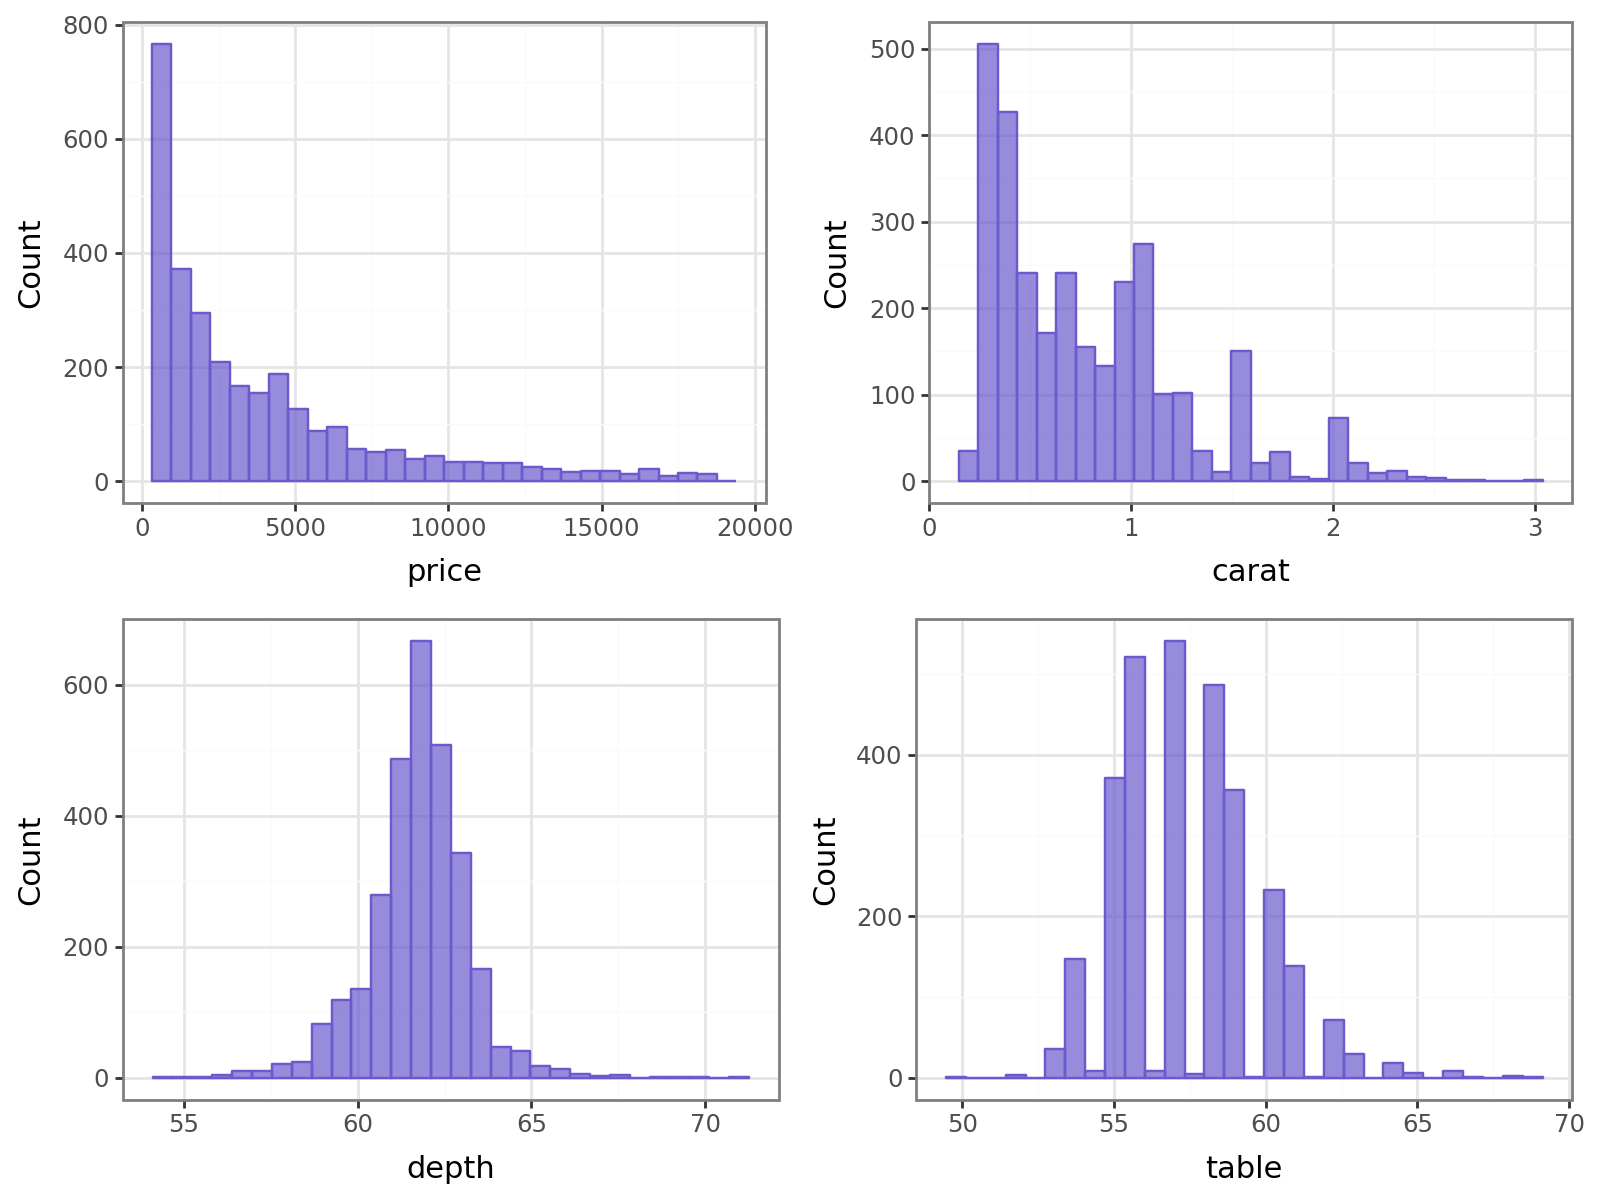

In [16]:
rsm.eda.visualize(diamonds, x=["price", "carat", "depth", "table"], geom="hist", ncol=2)

© Vincent Nijs (2026)